# Ranking Signal Analysis Using Random Forest on FlyRank Search Intelligence Data

## Author
Hammal Baloch

## Internship
FlyRank Machine Learning Internship – Capstone Project

## Research Question

Which content and search intelligence signals have the greatest influence on search ranking performance?

---

## Objective

The objective of this research is to identify the most influential ranking signals using machine learning. A Random Forest Regressor is trained on FlyRank Search Intelligence data to predict average search position and determine which content, traffic, and engagement features contribute most to search visibility. The findings provide practical recommendations for improving SEO performance and content strategy.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("content_refresh_anonymized.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4661, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


# 1. Dataset Description

The dataset used in this study is the anonymized FlyRank Search Intelligence dataset. It contains content quality metrics, search demand, engagement statistics, traffic indicators, and SEO-related variables collected over a 90-day period.

The dataset includes approximately 30,000 records and 44 attributes covering content characteristics, search performance, and user engagement.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4661 entries, 0 to 4660
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              4661 non-null   object 
 1   client_id               4661 non-null   object 
 2   search_volume           4272 non-null   float64
 3   competition             4272 non-null   float64
 4   competition_level       4247 non-null   object 
 5   cpc                     4272 non-null   float64
 6   content_type            4661 non-null   object 
 7   main_intent             4290 non-null   object 
 8   word_count              3439 non-null   float64
 9   char_count              3439 non-null   float64
 10  provider_used           1356 non-null   object 
 11  model_used              3766 non-null   object 
 12  impressions_90d         4661 non-null   int64  
 13  clicks_90d              4661 non-null   int64  
 14  pageviews_90d           4661 non-null   

In [33]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4660
Columns: 44


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
search_volume,4272.0,162.448502,1417.538584,0.0,0.0,10.00,20.0000,40500.00
competition,4272.0,0.153219,0.289715,0.0,0.0,0.00,0.1400,1.00
cpc,4272.0,0.485044,2.019958,0.0,0.0,0.00,0.0025,39.99
word_count,3439.0,3090.995057,1433.271294,8.0,2420.5,2866.00,3662.0000,9059.00
char_count,3439.0,20627.867694,10185.830522,40.0,15737.0,19031.00,24011.5000,109344.00
impressions_90d,4661.0,5216.550740,15361.495480,1.0,72.0,691.00,3429.0000,295097.00
clicks_90d,4661.0,15.903883,70.949010,0.0,0.0,1.00,6.0000,2138.00
pageviews_90d,4661.0,46.933491,132.201764,0.0,2.0,8.00,31.0000,2440.00
sessions_90d,4661.0,35.788887,96.527212,1.0,2.0,7.00,26.0000,2078.00
users_90d,4661.0,34.576700,92.087015,1.0,2.0,7.00,25.0000,1992.00


In [34]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print("Missing Values:")
display(missing.sort_values(ascending=False))

Missing Values:


,0
provider_used,3304
word_count,1222
char_count,1222
char_count_tier,1222
word_count_tier,1222
model_used,895
trend_pct,515
cpc,389
competition,389
search_volume,389


In [35]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 2. Data Cleaning

Before training the model, the dataset was inspected for missing values, duplicate records, and inconsistent data types.

The following preprocessing steps were performed:

- Removed missing values in the target variable.
- Removed duplicate observations.
- Encoded categorical variables using Label Encoding.
- Selected relevant ranking signals for model training.

In [8]:
target = "avg_position"

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to understand the structure of the dataset and identify patterns within the ranking signals.

The analysis includes:

- Summary statistics
- Missing value analysis
- Correlation analysis
- Distribution of target variable
- Content type distribution
- Competition level distribution

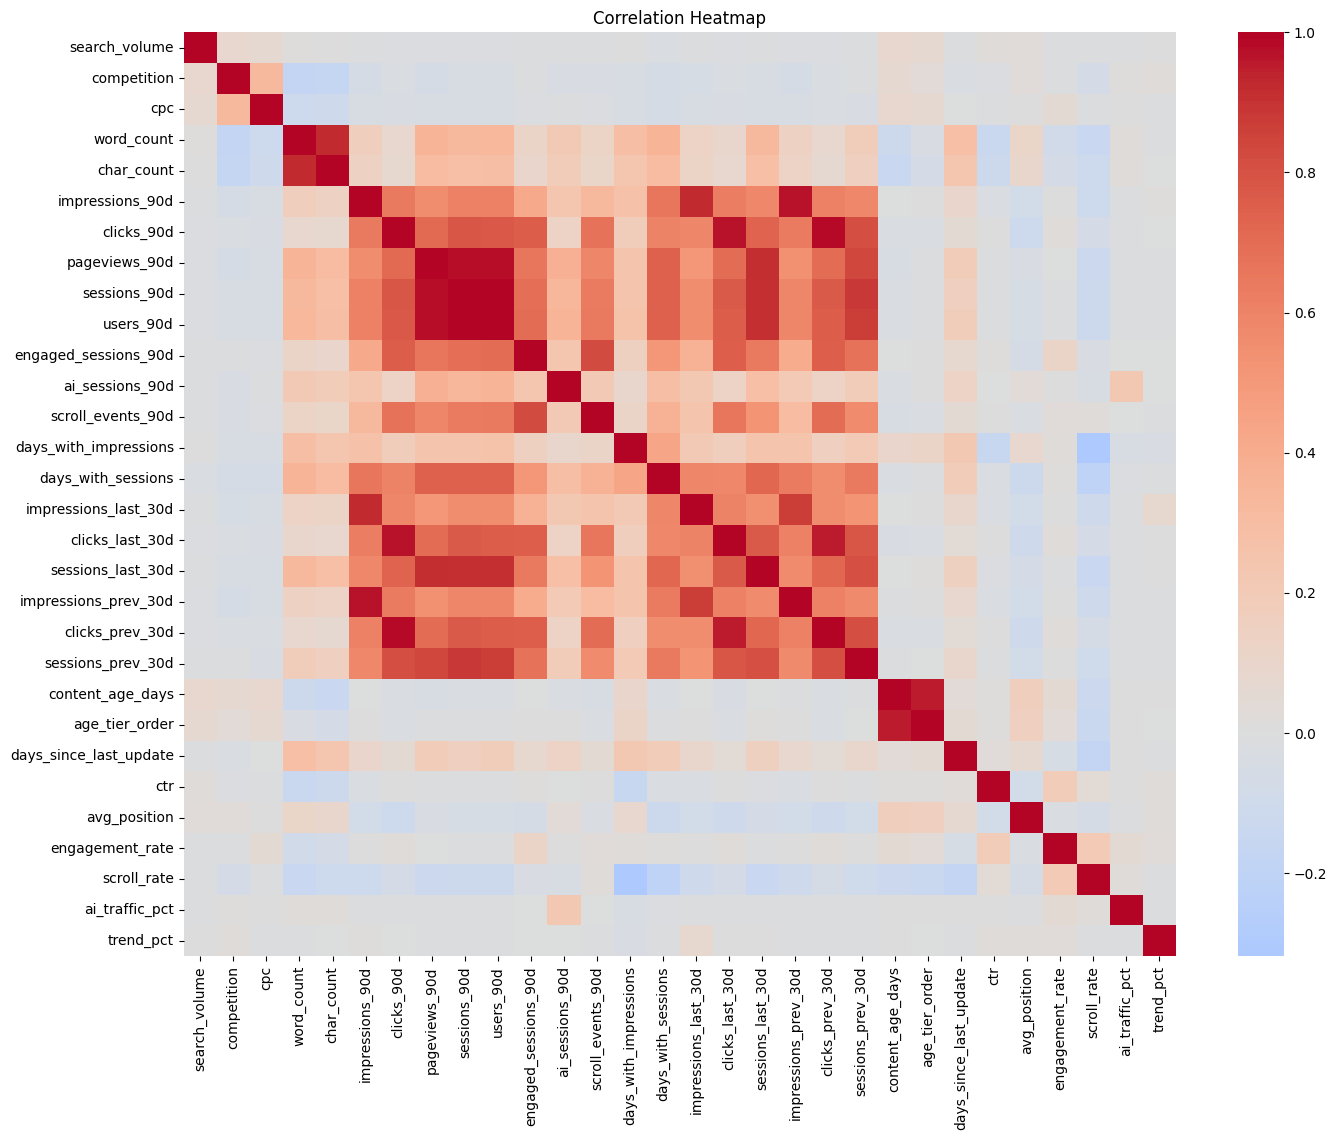

In [9]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.title("Correlation Heatmap")
plt.show()

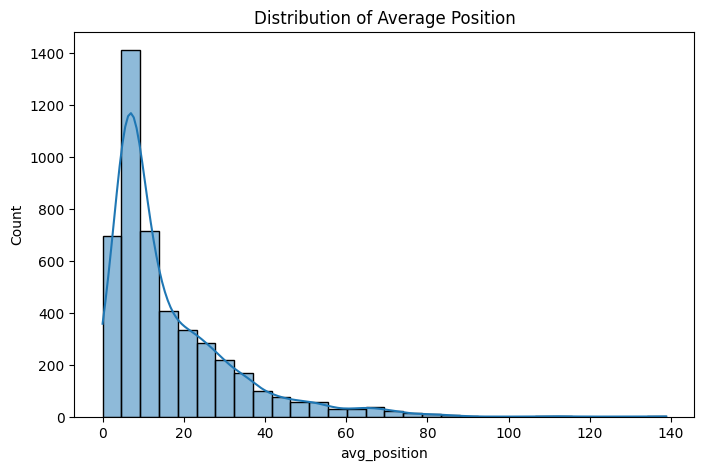

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["avg_position"],
             bins=30,
             kde=True)

plt.title("Distribution of Average Position")

plt.show()

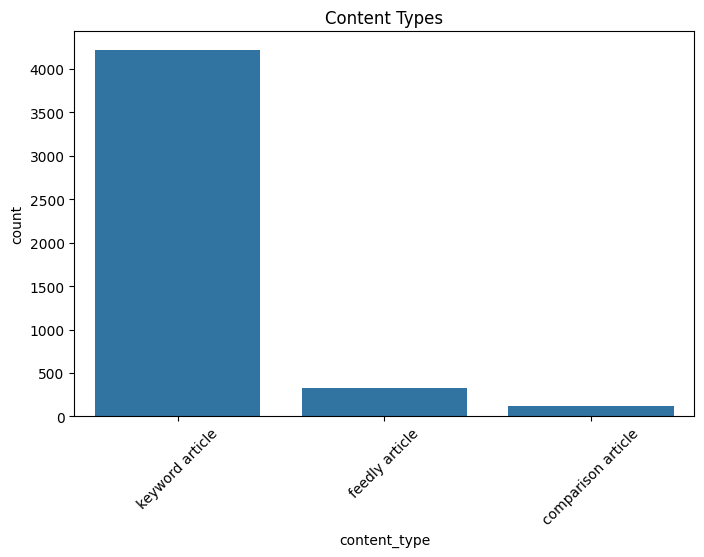

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="content_type")

plt.xticks(rotation=45)

plt.title("Content Types")

plt.show()

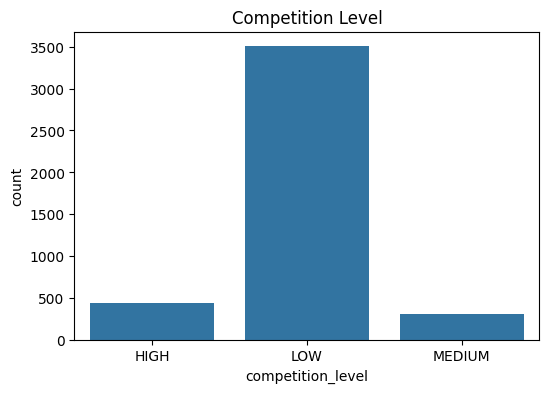

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="competition_level")

plt.title("Competition Level")

plt.show()

# 4. Feature Engineering

Relevant numerical and categorical features were selected to represent content quality, search demand, competition, traffic, and engagement.

Categorical variables were transformed into numerical values using Label Encoding to make them suitable for machine learning algorithms.

In [13]:
features = [
    "search_volume",
    "competition",
    "competition_level",
    "cpc",
    "content_type",
    "main_intent",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

In [14]:
categorical = [
    "competition_level",
    "content_type",
    "main_intent"
]

encoder = LabelEncoder()

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [23]:
X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(4660, 20)
(4660,)


# 5. Model Development

A Random Forest Regressor was selected because it captures nonlinear relationships between ranking signals and provides feature importance scores.

The dataset was divided into training and testing sets using an 80:20 split.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3728, 20)
Testing Set: (932, 20)


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


In [26]:
y_pred = rf.predict(X_test)

In [37]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# 6. Model Evaluation

The model was evaluated using three commonly used regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

These metrics assess prediction accuracy and overall model performance.

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

MAE : 8.487
RMSE: 12.738
R² Score: 0.286


In [38]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,5.6,6.2240
1,10.7,8.1640
2,23.7,23.2560
3,15.0,7.9930
4,6.5,9.9475
5,3.9,25.6920
6,9.3,17.5835
7,9.3,24.3595
8,12.1,12.5790
9,30.9,18.0080


# 7. Feature Importance Analysis

Random Forest provides feature importance scores that estimate the contribution of each ranking signal to the prediction of average search position.

Higher importance values indicate a stronger influence on ranking performance.

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
8,impressions_90d,0.168855
14,content_age_days,0.143486
6,word_count,0.098211
7,char_count,0.086895
16,ctr,0.080135
0,search_volume,0.059204
15,days_since_last_update,0.049224
1,competition,0.047171
18,scroll_rate,0.044832
9,clicks_90d,0.043247


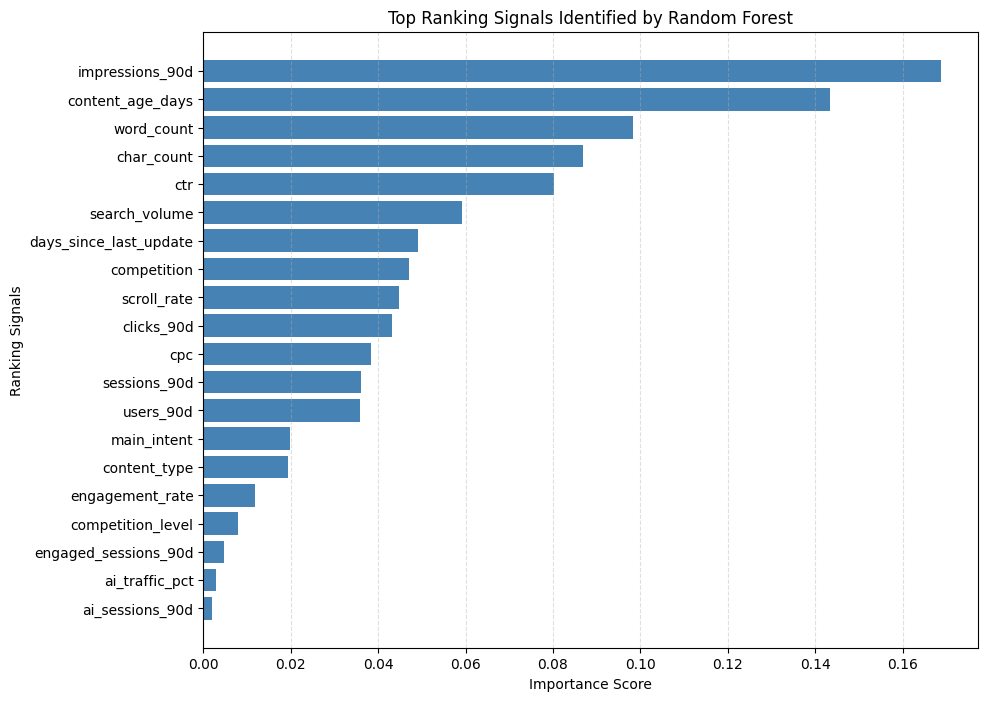

In [36]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"],
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Ranking Signals")
plt.title("Top Ranking Signals Identified by Random Forest")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

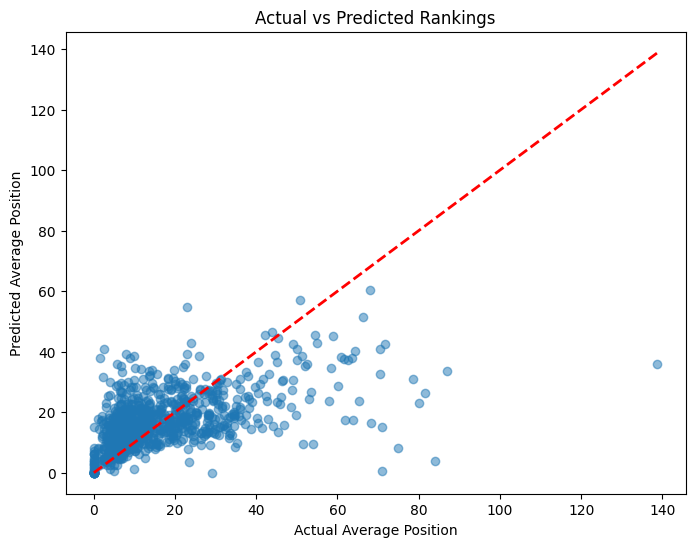

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Average Position")
plt.ylabel("Predicted Average Position")
plt.title("Actual vs Predicted Rankings")

plt.show()

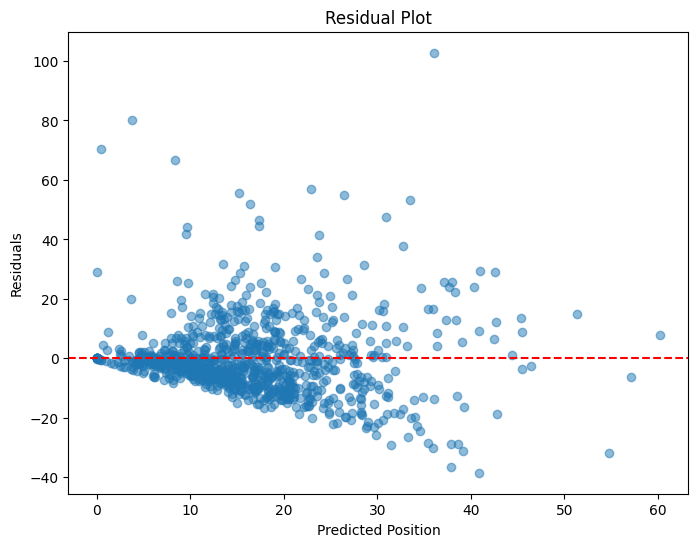

In [39]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Position")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [31]:
importance.to_csv("feature_importance.csv", index=False)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [32]:
importance.head(10)

,Feature,Importance
8,impressions_90d,0.168855
14,content_age_days,0.143486
6,word_count,0.098211
7,char_count,0.086895
16,ctr,0.080135
0,search_volume,0.059204
15,days_since_last_update,0.049224
1,competition,0.047171
18,scroll_rate,0.044832
9,clicks_90d,0.043247


# 8. Results

The Random Forest model achieved the following performance:

- MAE: 8.487
- RMSE: 12.738
- R² Score: 0.286

Feature importance analysis revealed that impressions over the last 90 days, content age, word count, character count, and click-through rate were the strongest ranking signals in the dataset.

# 9. Discussion

The analysis indicates that search visibility is influenced by multiple factors rather than a single metric. Content freshness, search impressions, content depth, and user engagement collectively contribute to ranking performance.

Although the predictive performance is moderate, the model successfully identifies meaningful ranking signals that can guide SEO decision-making.

# 10. Recommendations

Based on the findings, the following recommendations are proposed:

- Refresh older content regularly.
- Expand articles with low word counts.
- Improve pages receiving many impressions but few clicks.
- Enhance titles and meta descriptions to increase CTR.
- Prioritize optimization of high-potential content before creating new pages.

# 11. Limitations

This research is based on historical anonymized FlyRank data. Several external ranking factors, such as backlinks, technical SEO, and algorithm updates, were not included.

Therefore, the results should be interpreted as identifying associations rather than establishing direct causal relationships.

# 12. Conclusion

This study applied a Random Forest Regressor to identify important ranking signals using FlyRank Search Intelligence data.

The results demonstrate that impressions, content freshness, content length, and engagement metrics have the greatest influence on search ranking performance.

The proposed methodology provides an interpretable and reproducible framework for identifying optimization opportunities and supporting data-driven SEO strategies.

# 13. References

1. FlyRank Machine Learning Internship Dataset
2. Scikit-learn Documentation
3. Pandas Documentation
4. NumPy Documentation
5. Matplotlib Documentation